# Using SageMath for number theory, a tutorial

This is a short tutorial to get started with number fields and elliptic curves in SageMath. For a complete reference, see the official documentation:

- [The "getting started" tutorial](http://doc.sagemath.org/html/en/tutorial/index.html);
- [Other SageMath tutorials](http://doc.sagemath.org/html/en/thematic_tutorials/index.html);
- [Finite fields (reference)](http://doc.sagemath.org/html/en/reference/finite_rings/index.html);
- [Number fields](http://doc.sagemath.org/html/en/constructions/number_fields.html), [reference](http://doc.sagemath.org/html/en/reference/number_fields/index.html);
- [Quadratic forms (reference)](http://doc.sagemath.org/html/en/reference/quadratic_forms/index.html);
- [Elliptic curves](http://doc.sagemath.org/html/en/constructions/elliptic_curves.html), [reference](http://doc.sagemath.org/html/en/reference/curves/index.html).

See also the book [Computational Mathematics with SageMath](http://dl.lateralis.org/public/sagebook/sagebook-ba6596d.pdf).

## Rings and fields

Basic rings and fields

In [19]:
ZZ

Integer Ring

In [20]:
QQ

Rational Field

In [21]:
RR

Real Field with 53 bits of precision

In [22]:
CC

Complex Field with 53 bits of precision

The imaginary unit

In [23]:
i, I, i^2

(I, I, -1)

the `parent()` / `.parent()` function/method call is useful to recognize the algebraic structure in which an element lives

In [24]:
2.parent()

Integer Ring

In [25]:
parent(sqrt(2)/sqrt(2))

Symbolic Ring

In [26]:
(3.0).parent()

Real Field with 53 bits of precision

In [27]:
(3*i).parent()

Number Field in I with defining polynomial x^2 + 1 with I = 1*I

In [28]:
(3.0 * i).parent()

Complex Field with 53 bits of precision

### Finite fields

In [29]:
Fp = GF(11)
Fp

Finite Field of size 11

In [30]:
Fq = GF(11^3)
Fq

Finite Field in z3 of size 11^3

For extension fields, the generator is obtained with the `.gen()` function.

In [31]:
z = Fq.gen()
z

z3

In [32]:
z^120

8*z3^2 + z3 + 6

In [33]:
z.multiplicative_order()

1330

Same thing in one go

In [34]:
K.<t> = GF(next_prime(2^128)^2)
t.minimal_polynomial()

x^2 + x + 340282366920938463463374607431768211506

In [35]:
t.parent()

Finite Field in t of size 340282366920938463463374607431768211507^2

In [36]:
t.minimal_polynomial()

x^2 + x + 340282366920938463463374607431768211506

You can also specify the generator of the field extension.

In [37]:
# R.<x> = GF(11)['x']
# Fq.<a> = GF(11^2, modulus = x^2+1)
# a == Fq.gen()
Fq.<a> = GF(2^100)
a.multiplicative_order() == 2^100 - 1

True

In [38]:
a.minimal_polynomial()

x^100 + x^57 + x^56 + x^55 + x^52 + x^48 + x^47 + x^46 + x^45 + x^44 + x^43 + x^41 + x^37 + x^36 + x^35 + x^34 + x^31 + x^30 + x^27 + x^25 + x^24 + x^22 + x^20 + x^19 + x^16 + x^15 + x^11 + x^9 + x^8 + x^6 + x^5 + x^3 + 1

### Number fields

In [39]:
R.<X, Y> = QQ['X', 'Y']
R

Multivariate Polynomial Ring in X, Y over Rational Field

In [40]:
R.<W> = QQ['W']
R

Univariate Polynomial Ring in W over Rational Field

In [41]:
(W^3 + 4*W + 9).is_irreducible()
(W^2 - 9).roots()

[(3, 1), (-3, 1)]

In [42]:
K.<w> = NumberField(W^3 + 4*W + 9)
K

Number Field in w with defining polynomial W^3 + 4*W + 9

In [43]:
K.discriminant().factor()

-1 * 7 * 349

In [44]:
K.class_group()

Class group of order 2 with structure C2 of Number Field in w with defining polynomial W^3 + 4*W + 9

In [45]:
K.unit_group()

Unit group with structure C2 x Z of Number Field in w with defining polynomial W^3 + 4*W + 9

In [46]:
O = K.ring_of_integers()
O

Maximal Order generated by w in Number Field in w with defining polynomial W^3 + 4*W + 9

In [47]:
I = O.ideal(w + 3)
I

Ideal (3*w^2 + 3, 7*w^2 + w, 10*w^2) of Maximal Order generated by w in Number Field in w with defining polynomial W^3 + 4*W + 9

In [50]:
I.is_principal?

Signature:      I.is_principal(self)
Docstring:     
Return "True" if the ideal is principal in the ring containing the
ideal.

Todo: Code is naive. Only keeps track of ideal generators as set
during initialization of the ideal. (Can the base ring change? See
example below.)

EXAMPLES:

   sage: R.<x> = ZZ[]
   sage: I = R.ideal(2, x)
   sage: I.is_principal()
   Traceback (most recent call last):
   ...
   NotImplementedError
   sage: J = R.base_extend(QQ).ideal(2, x)
   sage: J.is_principal()
   True
Init docstring: Initialize self.  See help(type(self)) for accurate signature.
File:           /nix/store/7rqx0pi7v8ymf8h8iq2hbcc6jab98mh4-python3-3.13.12-env/lib/python3.13/site-packages/sage/rings/ideal.py
Type:           method

### Quadratic number fields

In [51]:
K.<w> = NumberField(W^2 + 11)
K

Number Field in w with defining polynomial W^2 + 11

In [68]:
O = K.maximal_order()
O

Maximal Order generated by 1/2*w + 1/2 in Number Field in w with defining polynomial W^2 + 11

In [53]:
I = O.ideal(w+3)
I

Ideal (7*w + 1, 10*w) of Maximal Order generated by 1/2*w + 1/2 in Number Field in w with defining polynomial W^2 + 11

In [54]:
I.is_principal()

True

In [65]:
J.<v> = QuadraticField(-11)

In [58]:
J == K

False

In [63]:
J.is_isomorphic(K)

True

In [64]:
f1, f2 = J.embeddings(K)
f1, f2

(Ring morphism:
   From: Number Field in v with defining polynomial x^2 + 11 with v = 3.316624790355400?*I
   To:   Number Field in w with defining polynomial W^2 + 11
   Defn: v |--> -w,
 Ring morphism:
   From: Number Field in v with defining polynomial x^2 + 11 with v = 3.316624790355400?*I
   To:   Number Field in w with defining polynomial W^2 + 11
   Defn: v |--> w)

In [66]:
f1(-v + 3) in I

True

### Exercise

Compute the unit and class groups of your "birtdhay number field".

In [93]:
Q.<X> = QQ['X']
K.<a> = NumberField(X^3 + 4*X + 15)

print("Ring Of Integers:", K.ring_of_integers())
print("Unit Group:", K.unit_group())
print("Class Group:", K.class_group())

Ring Of Integers: Maximal Order generated by a in Number Field in a with defining polynomial X^3 + 4*X + 15
Unit Group: Unit group with structure C2 x Z of Number Field in a with defining polynomial X^3 + 4*X + 15
Class Group: Class group of order 8 with structure C8 of Number Field in a with defining polynomial X^3 + 4*X + 15


### Quaternion algebras

In [80]:
Bpoo = QuaternionAlgebra(-1, -11)
Bpoo

Quaternion Algebra (-1, -11) with base ring Rational Field

In [81]:
O = Bpoo.maximal_order()
O

Order of Quaternion Algebra (-1, -11) with base ring Rational Field with basis (1/2 + 1/2*j, 1/2*i + 1/2*k, j, k)

## Elliptic curves

### Curves over $ℚ$

In [82]:
E = EllipticCurve([4,9])
E

Elliptic Curve defined by y^2 = x^3 + 4*x + 9 over Rational Field

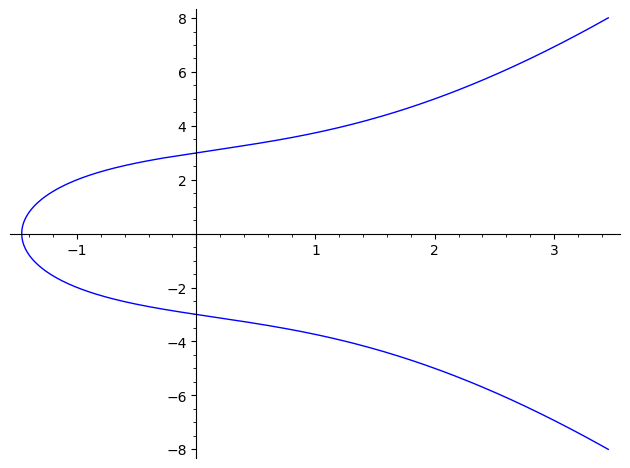

In [84]:
E.plot()

In [85]:
P = E(0,3)
P

(0 : 3 : 1)

In [88]:
Q = E.lift_x(0)
Q

(0 : -3 : 1)

In [89]:
Q == -P

True

In [91]:
show(13*P)

(-2411848366970096636251647518539327472864970032596030416/1871187884459158941452134776694811586351183203991670561 : 3340128368572691788005969852024435145953270091918532372518043594406327579175257267/2559623538193012408057304334131729394842091091424162516491280956021217854019573809 : 1)

In [94]:
P.order()

+Infinity

In [95]:
E.torsion_subgroup()

Torsion Subgroup isomorphic to Trivial group associated to the Elliptic Curve defined by y^2 = x^3 + 4*x + 9 over Rational Field

In [96]:
E.rank()

2

### Exercise

Compute the group structure of your "birthday elliptic curve"

In [117]:
E = EllipticCurve([4, 15])
print(E.rank())
print(E.torsion_points())
E.gens()

1
[(0 : 1 : 0)]


[(-7/4 : 13/8 : 1)]

### Exercise 
Consider the elliptic curve $E: y^2 = x^3 + 45333x - 1978074$ over $\mathbb{Q}$. Check that the number of rational points of $E$ is finite and find all rational points. 

In [119]:
E = EllipticCurve([45333, -1978074])
print(E.torsion_points())

[(0 : 1 : 0), (42 : 0 : 1), (87 : -1620 : 1), (87 : 1620 : 1), (267 : -5400 : 1), (267 : 5400 : 1), (1167 : -40500 : 1), (1167 : 40500 : 1)]


### Cuvers over finite fields

In [120]:
F = EllipticCurve(GF(11), [1, 0])
F

Elliptic Curve defined by y^2 = x^3 + x over Finite Field of size 11

In [121]:
F.order()

12

In [122]:
F.cardinality()

12

In [123]:
F.points()

[(0 : 1 : 0),
 (0 : 0 : 1),
 (5 : 3 : 1),
 (5 : 8 : 1),
 (7 : 3 : 1),
 (7 : 8 : 1),
 (8 : 5 : 1),
 (8 : 6 : 1),
 (9 : 1 : 1),
 (9 : 10 : 1),
 (10 : 3 : 1),
 (10 : 8 : 1)]

In [124]:
P = F.random_point()
P

(9 : 10 : 1)

In [125]:
P.order()

6

In [126]:
F.abelian_group()

Additive abelian group isomorphic to Z/12 embedded in Abelian group of points on Elliptic Curve defined by y^2 = x^3 + x over Finite Field of size 11

### Exercise 
For each integer $n \in \{6, 7, \dots, 17,18\}$, find an elliptic curve $E_n$ over $\mathbb{F}_{11}$ with exactly $n$ rational points, i.e.  $\# E_n(\mathbb{F}_{11}) = n$.

*Remark: Later, in the elliptic curve lecture you will learn Hasse's theorem which explains why this is exercise has a solution.*

In [150]:
def hasse_curve(q, n):
    F = GF(q)
    for i in range(1, q):
        for j in range(1, q):
            try:
                Eij = EllipticCurve(F, [F(i), F(j)])
                if (len(Eij.rational_points()) == n):
                    return Eij
            except e:
                continue
       
for n in range(6, 18):
    print(hasse_curve(11, n))

Elliptic Curve defined by y^2 = x^3 + x + 8 over Finite Field of size 11


TypeError: catching classes that do not inherit from BaseException is not allowed

### Curves over number fields

In [ ]:
K = QQ[i]
K

In [ ]:
E = EllipticCurve(K, j=0)
E

In [ ]:
E.torsion_order()

In [ ]:
E.torsion_points()

In [ ]:
E.rank()

In [ ]:
E = EllipticCurve(j=1)
E

In [ ]:
E.short_weierstrass_model()

In [ ]:
E.torsion_order()

In [ ]:
E.rank()

In [ ]:
P, Q = E.gens()
P, Q

In [ ]:
P.order()

Watch out: computing the rank is not always easy!

In [ ]:
EK = E.change_ring(K)
EK

In [ ]:
EK.rank()

### Multiplication

In [ ]:
F = EllipticCurve(GF(11), [1, 0])
g = F.gens()[0]
g

In [ ]:
12*g

In [ ]:
[(i, i*g) for i in range(12)]

Let's print the multiplication maps

In [ ]:
F.multiplication_by_m(12)

Using LaTeX-ified output is much nicer

In [ ]:
%display latex

In [ ]:
F.multiplication_by_m(12, x_only=True)

In [ ]:
m3 = F.multiplication_by_m(3)
m3

In [ ]:
d3 = m3[0].denominator()
d3

In [ ]:
parent(d3)

The multiplication maps are rational fractions in $x$ and $y$, so if we want the denominator as a polynomial in $x$ we need to convert it explicitly

In [ ]:
d3 = d3.univariate_polynomial()
parent(d3)

In [ ]:
d3.factor()

In [ ]:
psi3 = F.division_polynomial(3)
psi3

In [ ]:
psi3.factor()

In [ ]:
%display plain

### Exercise

Find a point of order 3 on the curve

If we change the base ring of the curve (e.g. from $𝔽_{11}$ to $𝔽_{121}$), more points appear

### Isomorphisms

In [ ]:
F = EllipticCurve(GF(11), [1, 0])
F

In [ ]:
F.automorphisms()

In [ ]:
aut = F.change_ring(GF(11^2)).automorphisms()
aut

In [ ]:
aut[3], aut[3]^2

In [ ]:
G = EllipticCurve(GF(11), [3, 0])
F.is_isomorphic(G)

In [ ]:
G

In [ ]:
G.j_invariant()

In [ ]:
u = F.isomorphism_to(G)
u

### Exercise

Consider the elliptic curves $E_1: y^2 = x^3 + x$, $E_2: y^2 = x^3 + 2x$ and $E_3:y^2 = x^3 + 3x$ over $\mathbb{F}_{11}$. Determine if $E_i$ and $E_j$ are isomorphic for $i,j \in \{1,2,3\}$.

Does the answer change if you change the base field to $\mathbb{F}_{11^2}$? 